### This notebook contains different machine learning models for evaluating the 

In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.stats import entropy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
features = pd.read_csv('../features.csv')
targets = pd.read_csv('../targets.csv')
data = features.merge(targets[['study_id','patient_id','case_ISUP']], on='study_id')
X = data.drop(['study_id','case_ISUP'], axis=1) # predictors
y = data['case_ISUP'] # target variable


In [3]:
df = X.copy() 
df["case_ISUP"] = y

idx_class0 = df.index[df["case_ISUP"] == 0]

# Storage for selected class-0 samples 
selected_class0 = []

# For each class 1–5, find nearest class-0 sample

for cls in range(1, 6): 
    print(f"Processing class {cls}") 
    idx_cls = df.index[df["case_ISUP"] == cls] 
    # Fit KNN on class 0 samples 
    knn = NearestNeighbors(n_neighbors=1) 
    knn.fit(df.loc[idx_class0, X.columns]) 
    # For each sample in class cls, find nearest class-0 sample 
    distances, indices = knn.kneighbors(df.loc[idx_cls, X.columns]) 
    # Convert neighbor indices to original dataframe indices 
    nearest_idx0 = idx_class0[indices.flatten()] 
    # Add to list 
    selected_class0.extend(nearest_idx0)

# keep only unique samples in class 0
selected_class0 = list(set(selected_class0)) 
print(f"\nOriginal class 0 count: {len(idx_class0)}") 
print(f"New class 0 count: {len(selected_class0)}")

# new reduced dataset
df_new = pd.concat([ df[df["case_ISUP"] != 0], # keep all minority classes 
                    df.loc[selected_class0] # keep only selected class-0 samples ])
])

print("\nFinal class counts:")
print(df_new["case_ISUP"].value_counts().sort_index())



Processing class 1
Processing class 2
Processing class 3
Processing class 4
Processing class 5

Original class 0 count: 589
New class 0 count: 262

Final class counts:
case_ISUP
0    262
1    157
2    154
3     69
4     27
5     35
Name: count, dtype: int64


In [4]:
# Binary classification: ISUP 0–2 → 0, ISUP 3–5 → 1
df_new["binary_target"] = (df_new["case_ISUP"] >= 3).astype(int)
X_bal = df_new.drop(columns=["case_ISUP", "binary_target"])
y_bal = df_new["binary_target"]

In [5]:
# Apply SMOTE to oversample class 1
sm = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = sm.fit_resample(X_bal, y_bal)

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_resampled).value_counts())


Class distribution AFTER SMOTE:
binary_target
0    573
1    573
Name: count, dtype: int64


In [ ]:
# Correlations
corrs = pd.Series(np.corrcoef(X_resampled.T, y_resampled)[-1, :-1])
corrs.index = X_bal.columns
corrs = corrs.abs().sort_values(ascending=False)

print("\nTop 10 correlated features:")
print(corrs.head(10))

features_all = X_bal.columns
features_20 = corrs.head(20).index
features_10 = corrs.head(10).index

feature_sets = {
    "All features": features_all,
    "Top 20 features": features_20,
    "Top 10 features": features_10
}



Top correlated features:
original_firstorder_Skewness             0.156437
original_shape_MeshVolume                0.135513
original_shape_VoxelVolume               0.135505
original_ngtdm_Strength                  0.127186
original_firstorder_Kurtosis             0.123709
original_shape_Maximum2DDiameterSlice    0.120313
original_shape_MajorAxisLength           0.119476
original_shape_SurfaceArea               0.119070
original_glcm_Idmn                       0.117783
original_shape_Maximum3DDiameter         0.116412
dtype: float64


In [7]:
# Model evaluation
def evaluate_models(X, y, label):
    
    print(f" Feature set: {label}")
    

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=5000),
        "KNN (k=3)": KNeighborsClassifier(n_neighbors=3),
        "Random Forest": RandomForestClassifier(
            n_estimators=300, max_depth=None, class_weight="balanced", random_state=42
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=1,  # balanced after SMOTE
            eval_metric="logloss",
            random_state=42
        )
    }

    roc_curves = {}
    for name, model in models.items():
        print(f"\n--- {name} ---")
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
        from sklearn.metrics import roc_curve, auc


        # Compute uncertainty for each sample
        uncertainty = entropy(np.vstack([y_prob, 1 - y_prob]), base=2)

        # Print average uncertainty
        print("Mean uncertainty:", uncertainty.mean())
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("ROC-AUC:", roc_auc_score(y_test, y_prob))
        print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
        print(classification_report(y_test, y_pred))
        
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        roc_curves[name] = (fpr, tpr, roc_auc)
        
        # Store curve for plotting
        roc_curves[name] = (fpr, tpr, roc_auc)

    # Plot of ROC curves
    plt.figure(figsize=(8, 6))
    for model_name, (fpr, tpr, roc_auc) in roc_curves.items():
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlim([0.0, 1.0]) 
    plt.ylim([0.0, 1.05]) 
    plt.xlabel('False Positive Rate') 
    plt.ylabel('True Positive Rate') 
    plt.title(f'ROC Curves — {label}') 
    plt.legend(loc="lower right") 
    plt.grid(True) 
    plt.show()

 Feature set: All features

--- Logistic Regression ---
Mean uncertainty: 0.8348411278171298
Accuracy: 0.7
ROC-AUC: 0.7637051039697542
Confusion matrix:
 [[77 38]
 [31 84]]
              precision    recall  f1-score   support

           0       0.71      0.67      0.69       115
           1       0.69      0.73      0.71       115

    accuracy                           0.70       230
   macro avg       0.70      0.70      0.70       230
weighted avg       0.70      0.70      0.70       230


--- KNN (k=3) ---
Mean uncertainty: 0.3313850183761853
Accuracy: 0.7782608695652173
ROC-AUC: 0.8660869565217391
Confusion matrix:
 [[ 66  49]
 [  2 113]]
              precision    recall  f1-score   support

           0       0.97      0.57      0.72       115
           1       0.70      0.98      0.82       115

    accuracy                           0.78       230
   macro avg       0.83      0.78      0.77       230
weighted avg       0.83      0.78      0.77       230


--- Random Forest

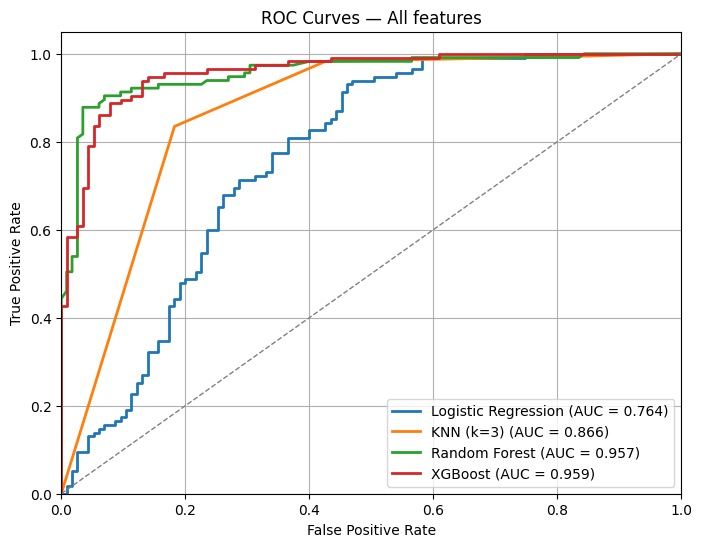

 Feature set: Top 20 features

--- Logistic Regression ---
Mean uncertainty: 0.9321464769080725
Accuracy: 0.6652173913043479
ROC-AUC: 0.6832514177693761
Confusion matrix:
 [[69 46]
 [31 84]]
              precision    recall  f1-score   support

           0       0.69      0.60      0.64       115
           1       0.65      0.73      0.69       115

    accuracy                           0.67       230
   macro avg       0.67      0.67      0.66       230
weighted avg       0.67      0.67      0.66       230


--- KNN (k=3) ---
Mean uncertainty: 0.3393701995418765
Accuracy: 0.7695652173913043
ROC-AUC: 0.809640831758034
Confusion matrix:
 [[ 67  48]
 [  5 110]]
              precision    recall  f1-score   support

           0       0.93      0.58      0.72       115
           1       0.70      0.96      0.81       115

    accuracy                           0.77       230
   macro avg       0.81      0.77      0.76       230
weighted avg       0.81      0.77      0.76       230




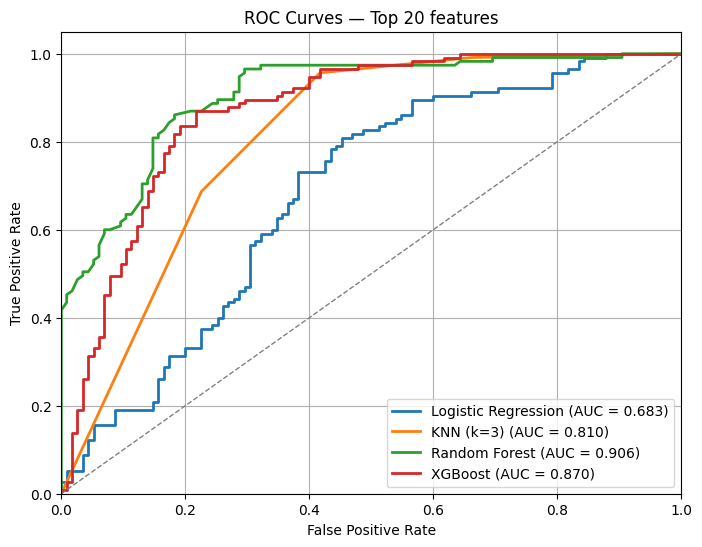

 Feature set: Top 10 features

--- Logistic Regression ---
Mean uncertainty: 0.9497195013196367
Accuracy: 0.6217391304347826
ROC-AUC: 0.6508128544423439
Confusion matrix:
 [[63 52]
 [35 80]]
              precision    recall  f1-score   support

           0       0.64      0.55      0.59       115
           1       0.61      0.70      0.65       115

    accuracy                           0.62       230
   macro avg       0.62      0.62      0.62       230
weighted avg       0.62      0.62      0.62       230


--- KNN (k=3) ---
Mean uncertainty: 0.40724423945025184
Accuracy: 0.7434782608695653
ROC-AUC: 0.8320604914933837
Confusion matrix:
 [[ 62  53]
 [  6 109]]
              precision    recall  f1-score   support

           0       0.91      0.54      0.68       115
           1       0.67      0.95      0.79       115

    accuracy                           0.74       230
   macro avg       0.79      0.74      0.73       230
weighted avg       0.79      0.74      0.73       230


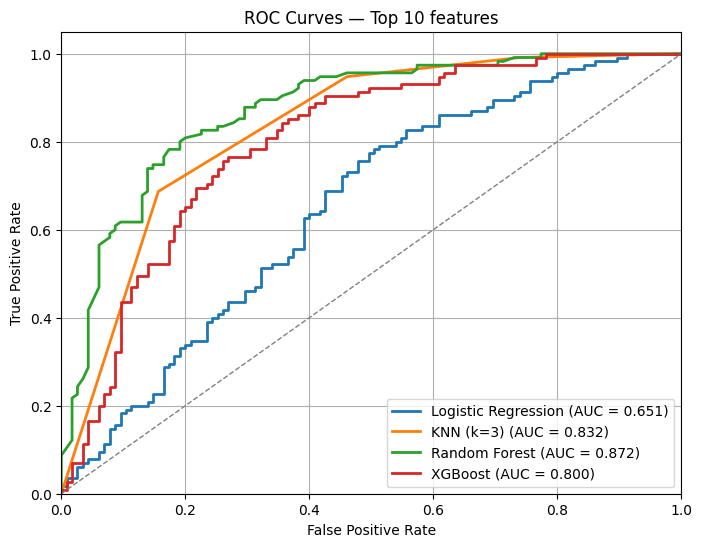

In [8]:
# Run evaluations
for label, feats in feature_sets.items():
    evaluate_models(X_resampled[feats], y_resampled, label)
